# Импорт библиотек

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [45]:
url = "https://raw.githubusercontent.com/Yorko/mlcourse.ai/main/data/wiki_machine_learning.csv"
df = pd.read_csv(url, sep='\s+')

print("Первые 5 строк данных:")
print(df.head())
print("\nИнформация о данных:")
print(df.info())
print(f"\nРазмер данных: {df.shape}")

df = df[df["count"] != 0]
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

print(f"\nДиапазон дат: от {df['date'].min()} до {df['date'].max()}")
print(f"Всего записей после очистки: {len(df)}")

Первые 5 строк данных:
          date  count lang              page  rank   month             title
81  2015-01-01   1414   en  Machine_learning  8708  201501  Machine_learning
80  2015-01-02   1920   en  Machine_learning  8708  201501  Machine_learning
79  2015-01-03   1338   en  Machine_learning  8708  201501  Machine_learning
78  2015-01-04   1404   en  Machine_learning  8708  201501  Machine_learning
77  2015-01-05   2264   en  Machine_learning  8708  201501  Machine_learning

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
Index: 384 entries, 81 to 372
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    384 non-null    object
 1   count   384 non-null    int64 
 2   lang    384 non-null    object
 3   page    384 non-null    object
 4   rank    384 non-null    int64 
 5   month   384 non-null    int64 
 6   title   384 non-null    object
dtypes: int64(3), object(4)
memory usage: 24.0+ KB
None

Размер данны

In [46]:
df

,date,count,lang,page,rank,month,title
81,2015-01-01,1414,en,Machine_learning,8708,201501,Machine_learning
80,2015-01-02,1920,en,Machine_learning,8708,201501,Machine_learning
79,2015-01-03,1338,en,Machine_learning,8708,201501,Machine_learning
78,2015-01-04,1404,en,Machine_learning,8708,201501,Machine_learning
77,2015-01-05,2264,en,Machine_learning,8708,201501,Machine_learning
...,...,...,...,...,...,...,...
382,2016-01-16,1644,en,Machine_learning,8708,201601,Machine_learning
381,2016-01-17,1836,en,Machine_learning,8708,201601,Machine_learning
376,2016-01-18,2983,en,Machine_learning,8708,201601,Machine_learning
375,2016-01-19,3389,en,Machine_learning,8708,201601,Machine_learning


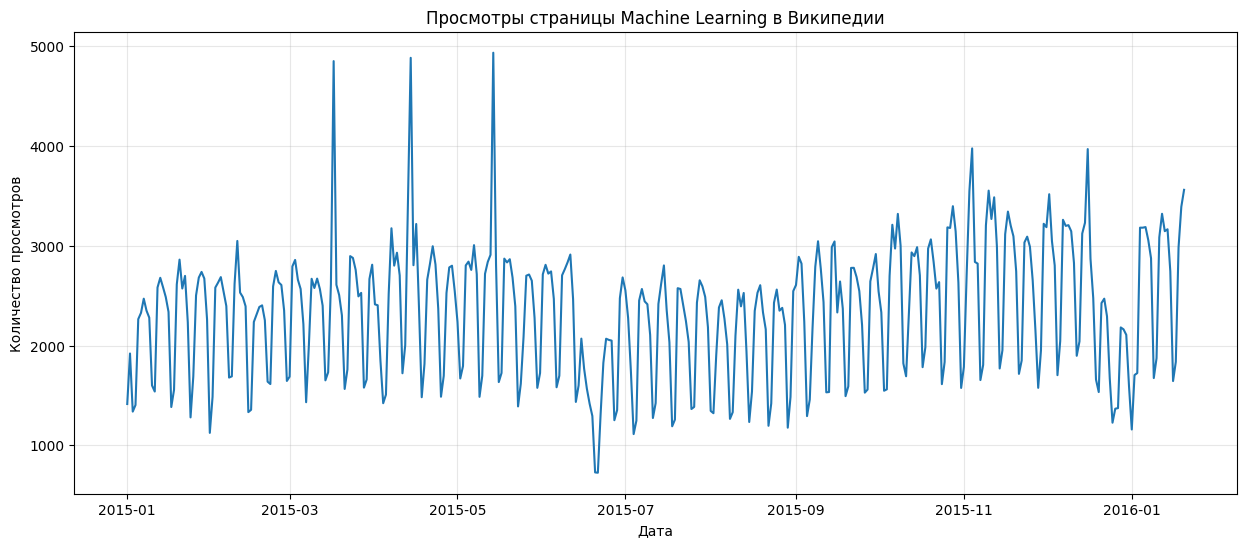

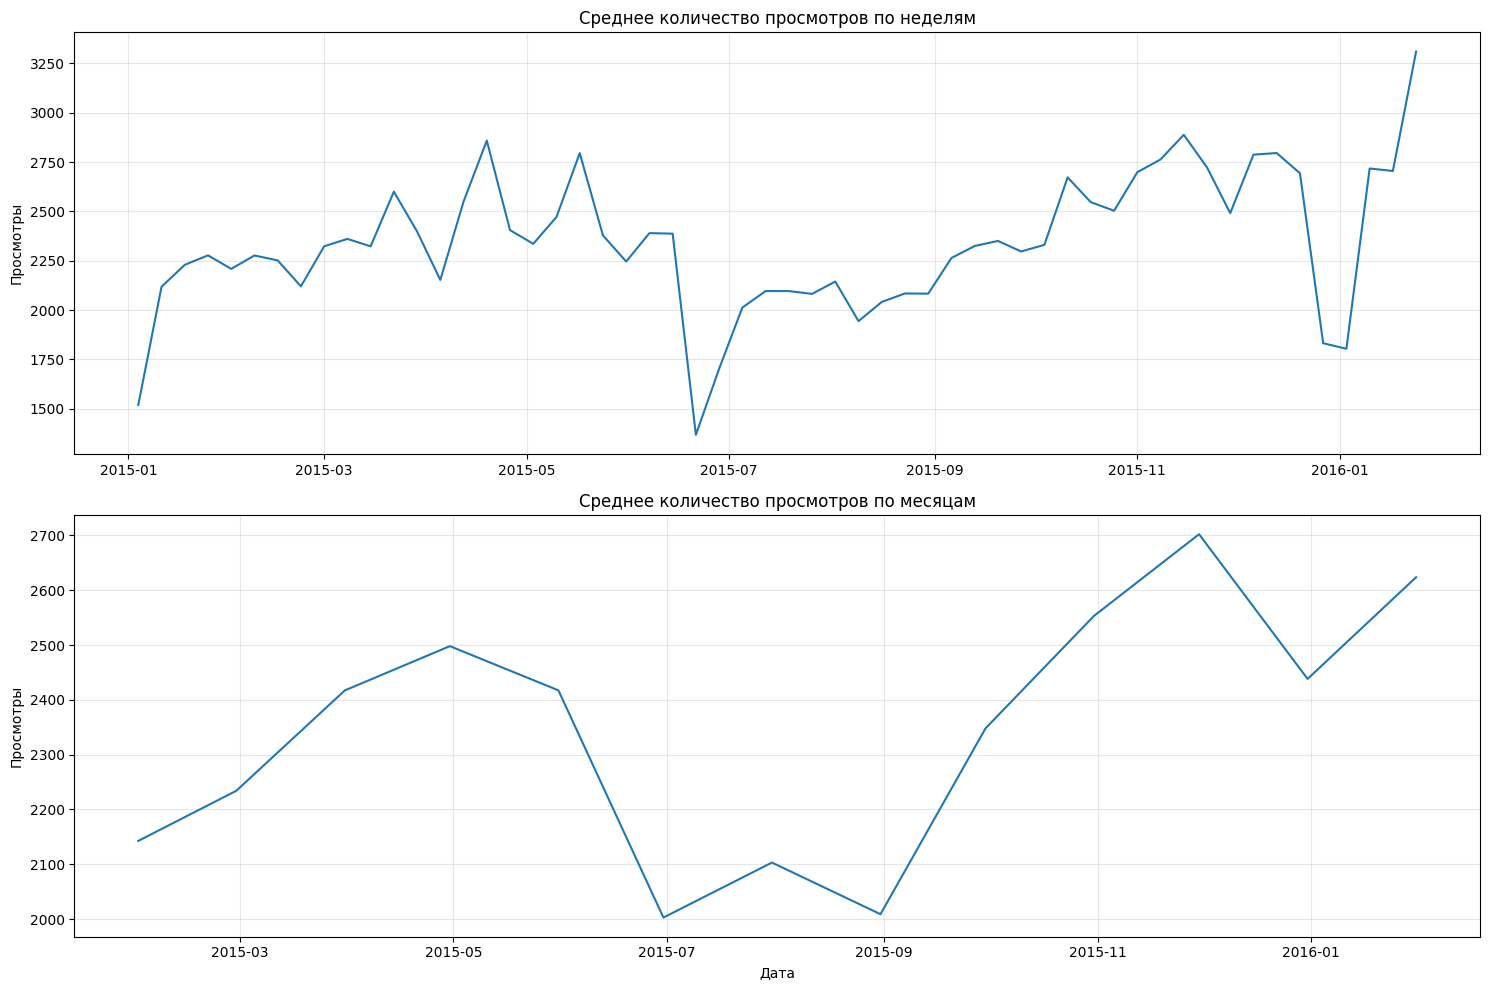

In [47]:
plt.figure(figsize=(15, 6))
plt.plot(df['date'], df['count'])
plt.title('Просмотры страницы Machine Learning в Википедии')
plt.xlabel('Дата')
plt.ylabel('Количество просмотров')
plt.grid(True, alpha=0.3)
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

df_weekly = df.set_index('date')['count'].resample('W').mean()
axes[0].plot(df_weekly)
axes[0].set_title('Среднее количество просмотров по неделям')
axes[0].set_ylabel('Просмотры')
axes[0].grid(True, alpha=0.3)

df_monthly = df.set_index('date')['count'].resample('M').mean()
axes[1].plot(df_monthly)
axes[1].set_title('Среднее количество просмотров по месяцам')
axes[1].set_ylabel('Просмотры')
axes[1].set_xlabel('Дата')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Часть 1: Предсказание с помощью Facebook Prophet

In [48]:
df_prophet = df[['date', 'count']].copy()
df_prophet.columns = ['ds', 'y']

predictions = 30
train_df = df_prophet[:-predictions].copy()
test_df = df_prophet[-predictions:].copy()

print(f"Размер обучающей выборки: {len(train_df)}")
print(f"Размер тестовой выборки: {len(test_df)}")
print(f"Даты обучающей выборки: {train_df['ds'].min()} - {train_df['ds'].max()}")
print(f"Даты тестовой выборки: {test_df['ds'].min()} - {test_df['ds'].max()}")

Размер обучающей выборки: 353
Размер тестовой выборки: 30
Даты обучающей выборки: 2015-01-01 00:00:00 - 2015-12-21 00:00:00
Даты тестовой выборки: 2015-12-22 00:00:00 - 2016-01-20 00:00:00


In [49]:
model = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
    seasonality_mode='multiplicative',
    changepoint_prior_scale=0.05
)

model.fit(train_df)

future = model.make_future_dataframe(periods=predictions)
forecast = model.predict(future)

jan_20_2016 = pd.Timestamp('2016-01-20')
forecast_jan_20 = forecast[forecast['ds'] == jan_20_2016]

if not forecast_jan_20.empty:
    prediction_value = forecast_jan_20['yhat'].values[0]
    print(f"Предсказание на 20 января 2016: {prediction_value:.0f}")
else:
    forecast_jan_20 = forecast[forecast['ds'] >= jan_20_2016].iloc[0]
    prediction_value = forecast_jan_20['yhat']
    print(f"Ближайшее предсказание к 20 января 2016: {prediction_value:.0f}")

Предсказание на 20 января 2016: 3517


In [50]:
forecast_test = forecast[-predictions:].reset_index(drop=True)
test_df_reset = test_df.reset_index(drop=True)

mae_prophet = mean_absolute_error(test_df_reset['y'], forecast_test['yhat'])
mape_prophet = mean_absolute_percentage_error(test_df_reset['y'], forecast_test['yhat']) * 100
rmse_prophet = np.sqrt(mean_squared_error(test_df_reset['y'], forecast_test['yhat']))

print(f"MAPE = {mape_prophet:.2f}%")
print(f"MAE = {mae_prophet:.2f}")
print(f"RMSE = {rmse_prophet:.2f}")

print("\nДетальная оценка качества Prophet:")
for i in range(min(10, len(test_df_reset))):
    actual = test_df_reset.loc[i, 'y']
    predicted = forecast_test.loc[i, 'yhat']
    error = abs(actual - predicted)
    error_percent = abs(actual - predicted) / actual * 100
    print(f"День {i+1}: Факт={actual:.0f}, Прогноз={predicted:.0f}, Ошибка={error:.0f} ({error_percent:.1f}%)")

MAPE = 23.24%
MAE = 406.61
RMSE = 598.22

Детальная оценка качества Prophet:
День 1: Факт=2469, Прогноз=3183, Ошибка=714 (28.9%)
День 2: Факт=2292, Прогноз=3048, Ошибка=756 (33.0%)
День 3: Факт=1671, Прогноз=2921, Ошибка=1250 (74.8%)
День 4: Факт=1227, Прогноз=2545, Ошибка=1318 (107.4%)
День 5: Факт=1367, Прогноз=1547, Ошибка=180 (13.2%)
День 6: Факт=1373, Прогноз=1698, Ошибка=325 (23.6%)
День 7: Факт=2181, Прогноз=2833, Ошибка=652 (29.9%)
День 8: Факт=2162, Прогноз=3115, Ошибка=953 (44.1%)
День 9: Факт=2107, Прогноз=2995, Ошибка=888 (42.1%)
День 10: Факт=1590, Прогноз=2885, Ошибка=1295 (81.4%)


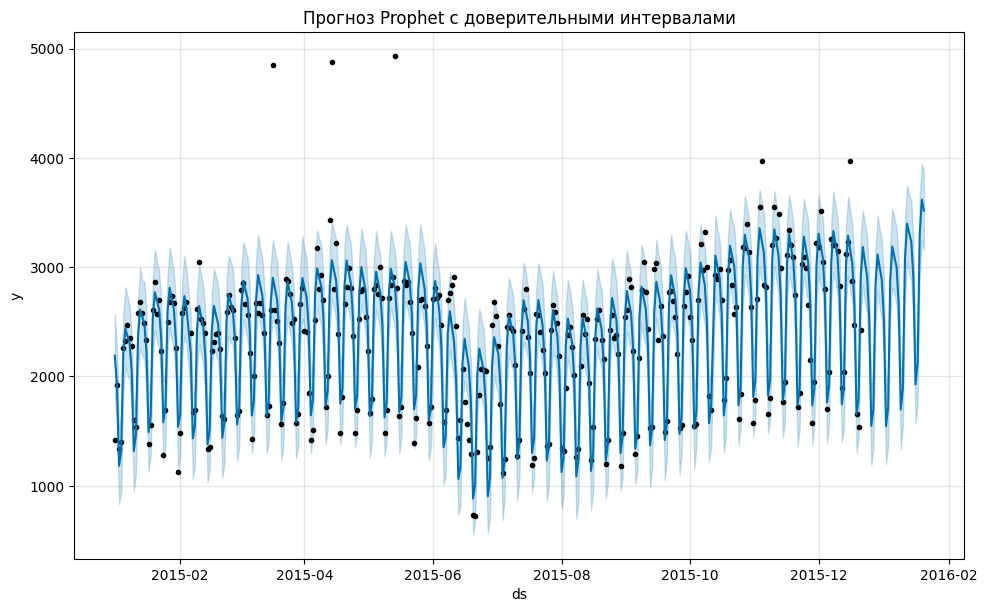

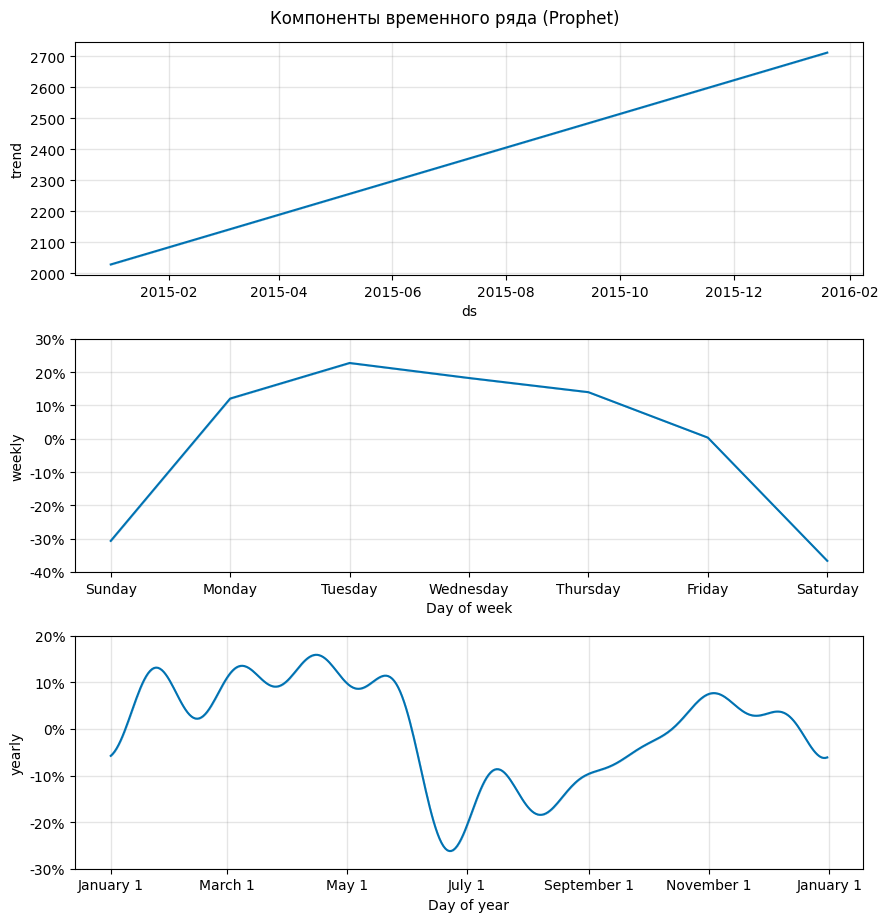

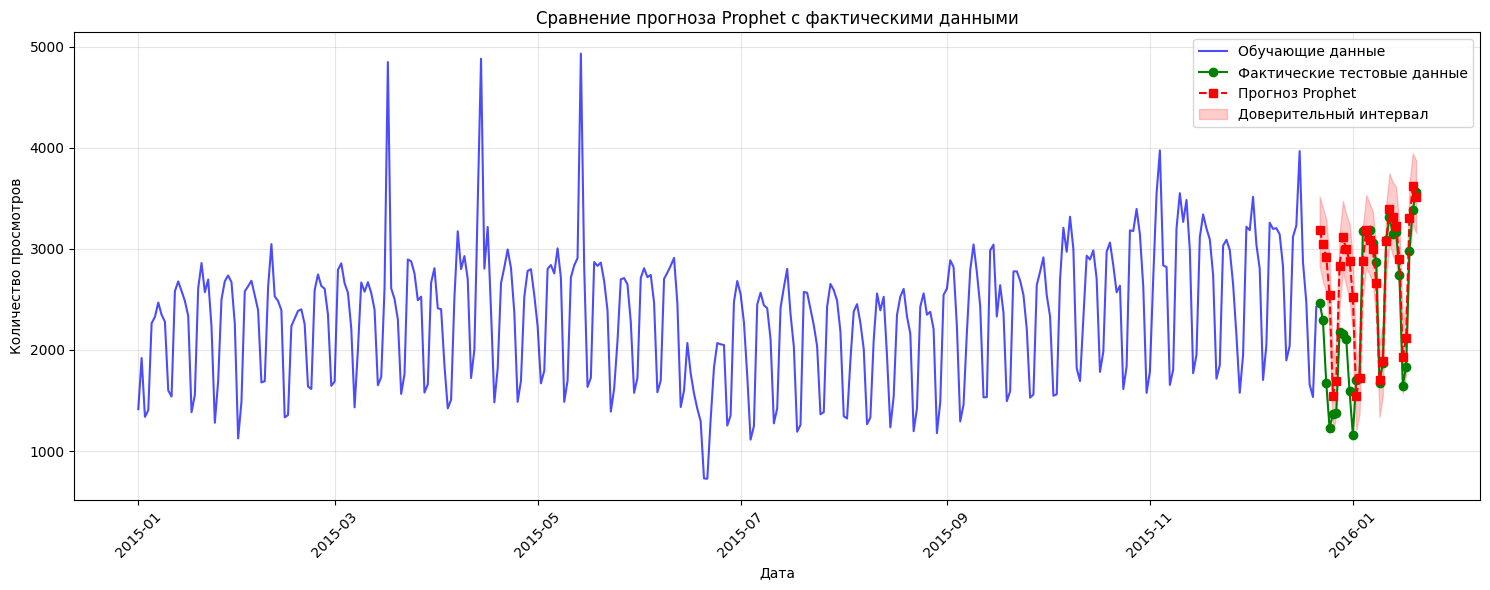

In [51]:
fig1 = model.plot(forecast)
plt.title('Прогноз Prophet с доверительными интервалами')
plt.show()

fig2 = model.plot_components(forecast)
plt.suptitle('Компоненты временного ряда (Prophet)', y=1.02)
plt.show()

plt.figure(figsize=(15, 6))
plt.plot(train_df['ds'], train_df['y'], label='Обучающие данные', color='blue', alpha=0.7)
plt.plot(test_df['ds'], test_df['y'], label='Фактические тестовые данные', color='green', marker='o')
plt.plot(forecast_test['ds'], forecast_test['yhat'], label='Прогноз Prophet', color='red', linestyle='--', marker='s')
plt.fill_between(forecast_test['ds'],
                 forecast_test['yhat_lower'],
                 forecast_test['yhat_upper'],
                 alpha=0.2, color='red', label='Доверительный интервал')
plt.title('Сравнение прогноза Prophet с фактическими данными')
plt.xlabel('Дата')
plt.ylabel('Количество просмотров')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [52]:
from statsmodels.tsa.stattools import adfuller

ts_data = df.set_index('date')['count']

adf_result = adfuller(ts_data, autolag='AIC')
adf_statistic = adf_result[0]
adf_pvalue = adf_result[1]

print("РЕЗУЛЬТАТЫ ТЕСТА ДИКИ-ФУЛЛЕРА:")
print("=" * 40)
print(f"ADF статистика: {adf_statistic:.6f}")
print(f"p-value: {adf_pvalue:.6f}")
print("\nКритические значения:")
for key, value in adf_result[4].items():
    print(f"  {key}: {value:.6f}")

print("\n" + "=" * 40)
if adf_pvalue < 0.05:
    print(f"p-value = {adf_pvalue:.6f} < 0.05 → Ряд СТАЦИОНАРЕН")
else:
    print(f"p-value = {adf_pvalue:.6f} >= 0.05 → Ряд НЕСТАЦИОНАРЕН")

РЕЗУЛЬТАТЫ ТЕСТА ДИКИ-ФУЛЛЕРА:
ADF статистика: -3.288864
p-value: 0.015384

Критические значения:
  1%: -3.448294
  5%: -2.869448
  10%: -2.570983

p-value = 0.015384 < 0.05 → Ряд СТАЦИОНАРЕН


# Часть 2: Анализ с помощью ARIMA/SARIMAX

In [53]:
from pmdarima import auto_arima

train_size = len(ts_data) - predictions
train_ts = ts_data[:train_size]
test_ts = ts_data[train_size:]

print("Автоматический подбор параметров SARIMA...")
print("Это может занять несколько минут...")

auto_model = auto_arima(
    train_ts,
    start_p=0, start_q=0,
    max_p=5, max_q=5,
    start_P=0, start_Q=0,
    max_P=2, max_Q=2,
    m=7,
    seasonal=True,
    d=None, D=None,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True,
    information_criterion='aic'
)

print("\n" + "=" * 40)
print(f"ЛУЧШАЯ МОДЕЛЬ ПО AIC КРИТЕРИЮ:")
print(f"Порядок (p,d,q): {auto_model.order}")
print(f"Сезонный порядок (P,D,Q,m): {auto_model.seasonal_order}")
print(f"AIC: {auto_model.aic():.2f}")
print("=" * 40)

print(f"\nЛучшая модель SARIMA имеет параметры:")
print(f"  order = {auto_model.order}")
print(f"  seasonal_order = {auto_model.seasonal_order}")

Автоматический подбор параметров SARIMA...
Это может занять несколько минут...
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=5538.729, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=5278.673, Time=0.61 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=5396.772, Time=0.68 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=5536.738, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[7] intercept   : AIC=5537.399, Time=0.05 sec
 ARIMA(1,1,0)(2,0,0)[7] intercept   : AIC=5229.658, Time=1.16 sec
 ARIMA(1,1,0)(2,0,1)[7] intercept   : AIC=5202.528, Time=1.73 sec
 ARIMA(1,1,0)(1,0,1)[7] intercept   : AIC=5201.008, Time=0.84 sec
 ARIMA(1,1,0)(0,0,1)[7] intercept   : AIC=5423.193, Time=0.34 sec
 ARIMA(1,1,0)(1,0,2)[7] intercept   : AIC=5202.316, Time=1.68 sec
 ARIMA(1,1,0)(0,0,2)[7] intercept   : AIC=5359.580, Time=0.62 sec
 ARIMA(1,1,0)(2,0,2)[7] intercept   : AIC=inf, Time=5.56 sec
 ARIMA(0,1,0)(1,0,1)[7] intercept   : AIC=5229.886, Time=0.72 sec
 ARIMA(2,1,0)(1,0,1)[7] i

In [54]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

best_order = auto_model.order
best_seasonal_order = auto_model.seasonal_order

print(f"\nОбучение SARIMA модели с параметрами:")
print(f"order={best_order}, seasonal_order={best_seasonal_order}")

sarima_model = SARIMAX(
    train_ts,
    order=best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_results = sarima_model.fit(disp=False)
print(sarima_results.summary())

forecast_sarima = sarima_results.get_forecast(steps=predictions)
forecast_mean = forecast_sarima.predicted_mean
forecast_conf_int = forecast_sarima.conf_int()

mae_sarima = mean_absolute_error(test_ts, forecast_mean)
mape_sarima = mean_absolute_percentage_error(test_ts, forecast_mean) * 100

print(f"\nКачество SARIMA на тестовых данных:")
print(f"MAE: {mae_sarima:.2f}")
print(f"MAPE: {mape_sarima:.2f}%")
print(f"AIC: {sarima_results.aic:.2f}")


Обучение SARIMA модели с параметрами:
order=(5, 1, 0), seasonal_order=(1, 0, 1, 7)
                                      SARIMAX Results                                      
Dep. Variable:                               count   No. Observations:                  353
Model:             SARIMAX(5, 1, 0)x(1, 0, [1], 7)   Log Likelihood               -2471.834
Date:                             Tue, 02 Dec 2025   AIC                           4959.668
Time:                                     13:35:55   BIC                           4990.300
Sample:                                          0   HQIC                          4971.873
                                             - 353                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4653 

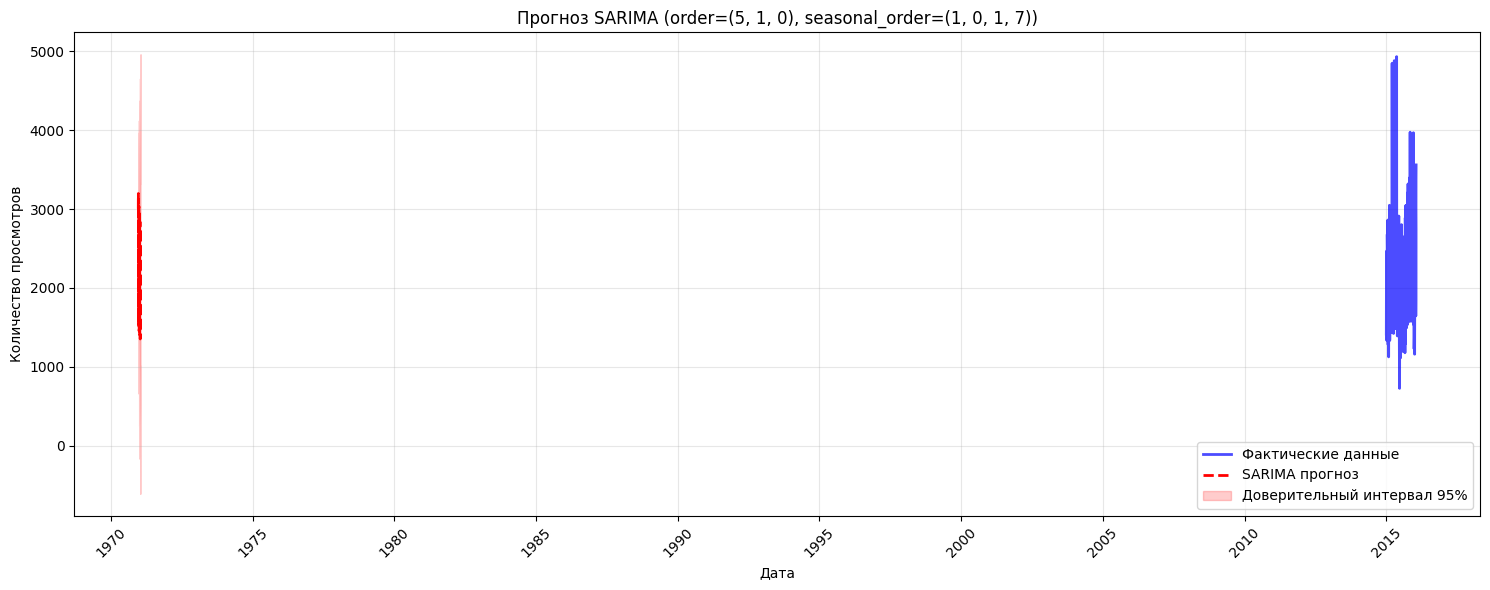

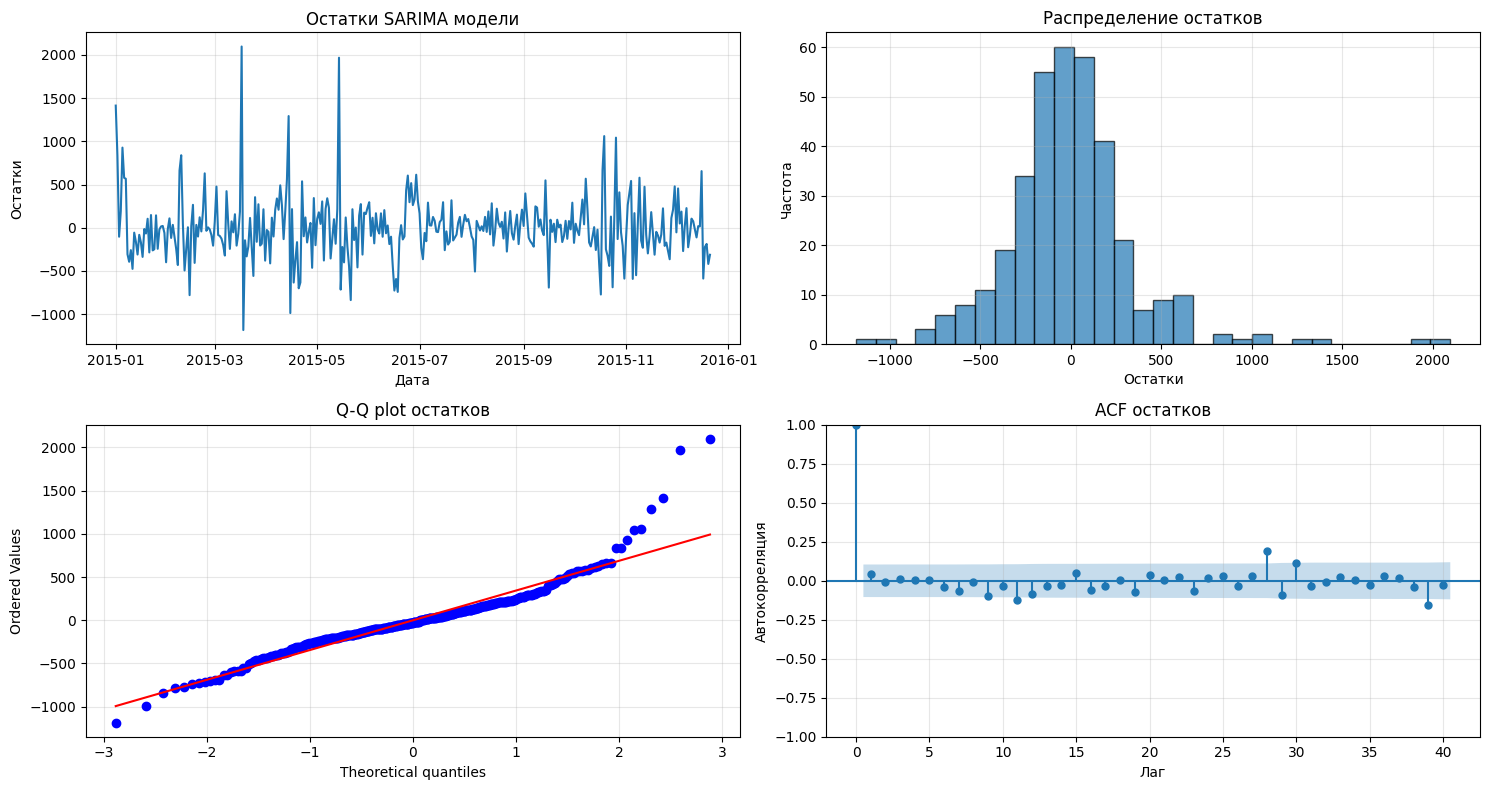

In [55]:
plt.figure(figsize=(15, 6))
plt.plot(ts_data.index, ts_data.values, label='Фактические данные', color='blue', alpha=0.7, linewidth=2)
plt.plot(forecast_mean.index, forecast_mean.values, label='SARIMA прогноз', color='red', linewidth=2, linestyle='--')
plt.fill_between(forecast_conf_int.index,
                 forecast_conf_int.iloc[:, 0],
                 forecast_conf_int.iloc[:, 1],
                 color='red', alpha=0.2, label='Доверительный интервал 95%')
plt.title(f'Прогноз SARIMA (order={best_order}, seasonal_order={best_seasonal_order})')
plt.xlabel('Дата')
plt.ylabel('Количество просмотров')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 8))

plt.subplot(2, 2, 1)
residuals = sarima_results.resid
plt.plot(residuals)
plt.title('Остатки SARIMA модели')
plt.xlabel('Дата')
plt.ylabel('Остатки')
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
plt.hist(residuals, bins=30, edgecolor='black', alpha=0.7)
plt.title('Распределение остатков')
plt.xlabel('Остатки')
plt.ylabel('Частота')
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 3)
from scipy import stats
stats.probplot(residuals.dropna(), dist="norm", plot=plt)
plt.title('Q-Q plot остатков')
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 4)
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuals.dropna(), lags=40, ax=plt.gca(), alpha=0.05)
plt.title('ACF остатков')
plt.xlabel('Лаг')
plt.ylabel('Автокорреляция')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

ТАБЛИЦА СРАВНЕНИЯ ПРОГНОЗОВ (первые 10 дней):
        Дата  Факт      Prophet       SARIMA
0 2015-12-22  2469  3183.459922  3004.764868
1 2015-12-23  2292  3048.417385  3196.384218
2 2015-12-24  1671  2921.197993  2668.427843
3 2015-12-25  1227  2544.961047  2394.733553
4 2015-12-26  1367  1547.044077  1527.184310
5 2015-12-27  1373  1697.587318  1520.234934
6 2015-12-28  2181  2832.733963  2565.214740
7 2015-12-29  2162  3115.285147  2835.034655
8 2015-12-30  2107  2994.943524  3032.309830
9 2015-12-31  1590  2884.608793  2581.034194


МЕТРИКИ КАЧЕСТВА МОДЕЛЕЙ:
 Метрика    Prophet     SARIMA
     MAE 406.612521 596.300423
MAPE (%)  23.235308  28.400365
    RMSE 598.216343        NaN


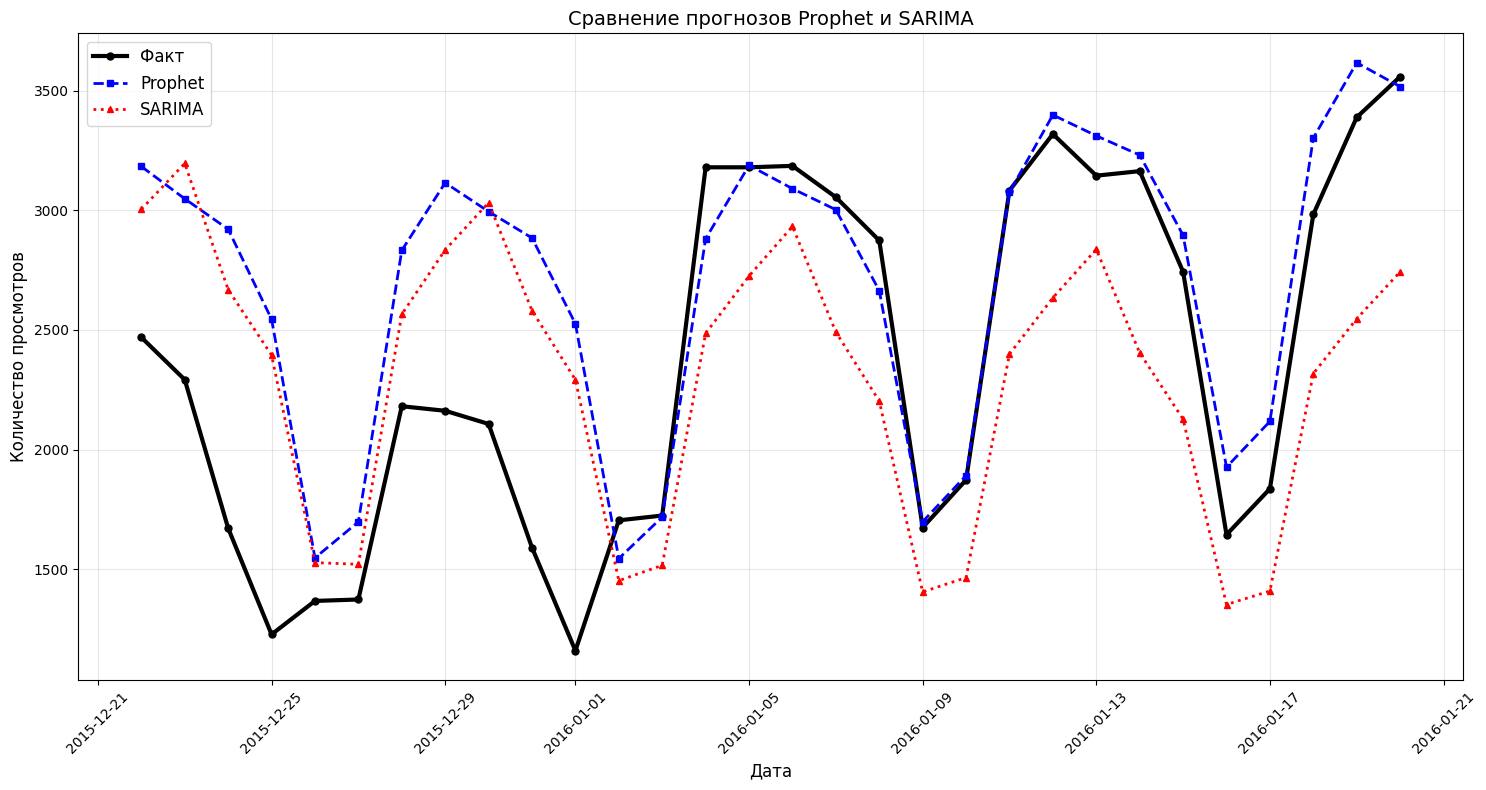

In [56]:
comparison_df = pd.DataFrame({
    'Дата': test_ts.index,
    'Факт': test_ts.values,
    'Prophet': forecast_test['yhat'].values,
    'SARIMA': forecast_mean.values
})

print("ТАБЛИЦА СРАВНЕНИЯ ПРОГНОЗОВ (первые 10 дней):")
print("=" * 70)
print(comparison_df.head(10).to_string())
print("\n" + "=" * 70)

print("\nМЕТРИКИ КАЧЕСТВА МОДЕЛЕЙ:")
print("=" * 70)
metrics_data = [
    ['MAE', mae_prophet, mae_sarima],
    ['MAPE (%)', mape_prophet, mape_sarima],
    ['RMSE', rmse_prophet, np.nan]
]

metrics_df = pd.DataFrame(metrics_data, columns=['Метрика', 'Prophet', 'SARIMA'])
print(metrics_df.to_string(index=False))
print("=" * 70)

plt.figure(figsize=(15, 8))
plt.plot(comparison_df['Дата'], comparison_df['Факт'], label='Факт',
         color='black', linewidth=3, marker='o', markersize=5)
plt.plot(comparison_df['Дата'], comparison_df['Prophet'], label='Prophet',
         color='blue', linewidth=2, linestyle='--', marker='s', markersize=4)
plt.plot(comparison_df['Дата'], comparison_df['SARIMA'], label='SARIMA',
         color='red', linewidth=2, linestyle=':', marker='^', markersize=4)
plt.title('Сравнение прогнозов Prophet и SARIMA', fontsize=14)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Количество просмотров', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()